## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip -q install kagglehub albumentations
!pip -q install -U ultralytics

In [3]:
import kagglehub
from pathlib import Path

dataset_path = kagglehub.dataset_download("aliabdelmenam/rdd-2022")
DATA_DIR = Path(dataset_path) / "RDD_SPLIT"

splits = ["train", "val", "test"]
for split in splits:
    imgs = len(list((DATA_DIR / split / "images").glob("*")))
    lbls = len(list((DATA_DIR / split / "labels").glob("*.txt")))
    print(f"{split}: {imgs} images, {lbls} labels")

Using Colab cache for faster access to the 'rdd-2022' dataset.
train: 26869 images, 26869 labels
val: 5758 images, 5758 labels
test: 5758 images, 5758 labels


## 2. Create writable copy + fix bad bbox

In [4]:
import shutil

WORK = Path("/content/RDD_V2/RDD_SPLIT")

if WORK.exists():
    shutil.rmtree(WORK)

shutil.copytree(DATA_DIR, WORK)
print("Copied to:", WORK)

Copied to: /content/RDD_V2/RDD_SPLIT


In [5]:
# Fix the one known bad bbox (Japan_001265.txt has a zero-width box)
target = WORK / "train" / "labels" / "Japan_001265.txt"
lines = target.read_text().splitlines()
cleaned = []

for line in lines:
    parts = line.strip().split()
    if len(parts) != 5:
        continue
    w, h = float(parts[3]), float(parts[4])
    if w > 0 and h > 0:
        cleaned.append(line.strip())
    else:
        print(f"Removed: {line.strip()}")

target.write_text("\n".join(cleaned) + "\n")
print(f"Kept {len(cleaned)} valid lines")

Removed: 2 0.330000 0.790833 0.000000 0.001667
Kept 3 valid lines


## 3. Merge crack subclasses

- 0,1,2 (D00, D10, D20) → **0 = crack**
- 3 (Other) → **1 = other**
- 4 (Pothole) → **2 = pothole**

In [6]:
class_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 2}
remapped = 0

for split in splits:
    for lbl in (WORK / split / "labels").glob("*.txt"):
        lines = [l.strip() for l in lbl.read_text().splitlines() if l.strip()]
        new_lines = []
        for line in lines:
            parts = line.split()
            if len(parts) != 5:
                continue
            old = int(parts[0])
            new = class_map[old]
            if old != new:
                remapped += 1
            new_lines.append(f"{new} {' '.join(parts[1:])}")
        lbl.write_text("\n".join(new_lines) + ("\n" if new_lines else ""))

# Verify
all_cls = set()
for split in splits:
    for lbl in (WORK / split / "labels").glob("*.txt"):
        for line in lbl.read_text().splitlines():
            p = line.strip().split()
            if len(p) == 5:
                all_cls.add(int(p[0]))

print(f"Remapped {remapped} lines")
print(f"Classes: {sorted(all_cls)}")

Remapped 39695 lines
Classes: [0, 1, 2]


## 4. Offline augmentation for pothole images

Instead of oversampling (repeating same images), create **new** augmented images.

| Transform | Why it's realistic |
|---|---|
| `HorizontalFlip` | Flipped road is still a natural road |
| `RandomBrightnessContrast` | Same road looks different at morning vs afternoon vs overcast |
| `GaussNoise` | Camera sensor noise in low light conditions |
| `MotionBlur` | Dashcam shooting at 80-120 km/h |

In [7]:
# Find all training images that contain potholes (class 2)
train_imgs = WORK / "train" / "images"
train_lbls = WORK / "train" / "labels"

pothole_imgs = []
for lbl in train_lbls.glob("*.txt"):
    for line in lbl.read_text().splitlines():
        if line.strip().startswith("2 "):
            img = train_imgs / (lbl.stem + ".jpg")
            if img.exists():
                pothole_imgs.append(img)
            break

print(f"Pothole images: {len(pothole_imgs)}")
print(f"Total train images: {len(list(train_imgs.glob('*.jpg')))}")

Pothole images: 2599
Total train images: 26869


In [8]:
import albumentations as A
import cv2

# 4 simple, realistic transforms — nothing exotic
aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=(-0.3, 0.25), contrast_limit=0.2, p=0.7),
    A.GaussNoise(std_range=(0.01, 0.05), p=0.25),
    A.MotionBlur(blur_limit=(3, 5), p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['cls'], min_visibility=0.3))

AUG_COPIES = 3  # 3 new images per pothole image
created = 0

for img_path in pothole_imgs:
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    # Read label
    lbl_path = train_lbls / (img_path.stem + ".txt")
    bboxes, cls = [], []
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            cls.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:]])

    if not bboxes:
        continue

    for i in range(AUG_COPIES):
        try:
            r = aug(image=img, bboxes=bboxes, cls=cls)
            if not r['bboxes']:
                continue

            name = f"{img_path.stem}_aug{i}"
            cv2.imwrite(str(train_imgs / f"{name}.jpg"), r['image'])

            with open(train_lbls / f"{name}.txt", 'w') as f:
                for c, b in zip(r['cls'], r['bboxes']):
                    f.write(f"{c} {b[0]:.6f} {b[1]:.6f} {b[2]:.6f} {b[3]:.6f}\n")
            created += 1
        except:
            pass

print(f"Created {created} augmented images")
print(f"Total train images now: {len(list(train_imgs.glob('*.jpg')))}")

Created 7788 augmented images
Total train images now: 34657


## 5. Quick EDA after merge + augmentation

In [10]:
# Fix float class IDs in augmented labels (e.g. "2.0" -> "2")
fixed = 0
for lbl in (WORK / "train" / "labels").glob("*_aug*.txt"):
    text = lbl.read_text()
    new_lines = []
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            parts[0] = str(int(float(parts[0])))
            new_lines.append(" ".join(parts))
    lbl.write_text("\n".join(new_lines) + "\n")
    fixed += 1

print(f"Fixed {fixed} label files")

Fixed 7788 label files


In [11]:
from collections import Counter

NAMES = {0: 'Crack', 1: 'Other', 2: 'Pothole'}

for split in splits:
    counts = Counter()
    total = 0
    n_imgs = len(list((WORK / split / "images").glob("*.jpg")))

    for lbl in (WORK / split / "labels").glob("*.txt"):
        for line in lbl.read_text().splitlines():
            p = line.strip().split()
            if len(p) == 5:
                counts[int(p[0])] += 1
                total += 1

    print(f"\n{split.upper()} — {n_imgs} images, {total:,} boxes")
    for i in range(3):
        c = counts.get(i, 0)
        pct = c / total * 100 if total else 0
        print(f"  {NAMES[i]:<10} {c:>7,}  ({pct:.1f}%)")

# Crack:Pothole ratio
t = Counter()
for lbl in (WORK / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().splitlines():
        p = line.strip().split()
        if len(p) == 5:
            t[int(p[0])] += 1

print(f"\nCrack:Pothole ratio = {t[0]/t[2]:.1f}:1  (V1 was ~4:1)")


TRAIN — 34657 images, 71,888 boxes
  Crack       43,467  (60.5%)
  Other        9,921  (13.8%)
  Pothole     18,500  (25.7%)

VAL — 5758 images, 9,741 boxes
  Crack        7,212  (74.0%)
  Other        1,564  (16.1%)
  Pothole        965  (9.9%)

TEST — 5758 images, 9,675 boxes
  Crack        7,137  (73.8%)
  Other        1,587  (16.4%)
  Pothole        951  (9.8%)

Crack:Pothole ratio = 2.3:1  (V1 was ~4:1)


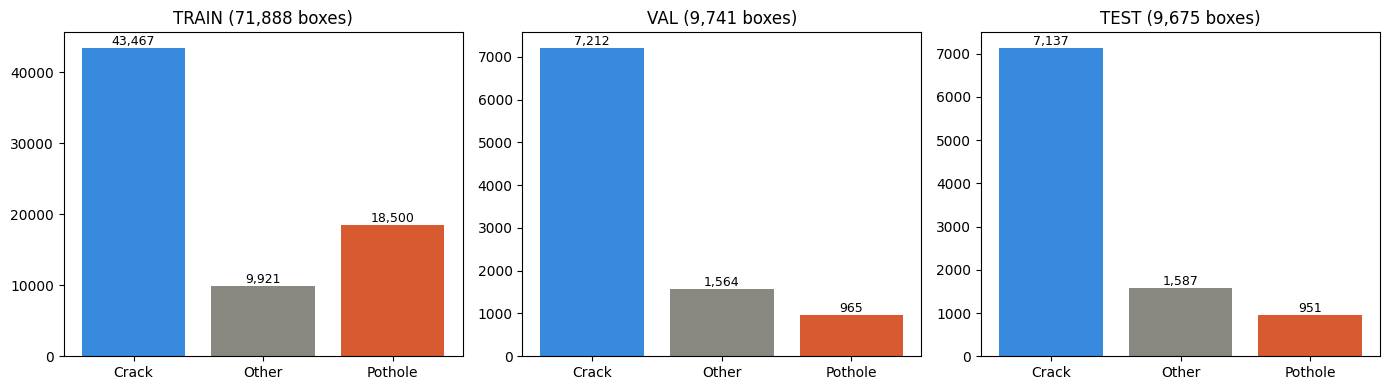

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#378ADD', '#888780', '#D85A30']

for idx, split in enumerate(splits):
    counts = Counter()
    for lbl in (WORK / split / "labels").glob("*.txt"):
        for line in lbl.read_text().splitlines():
            p = line.strip().split()
            if len(p) == 5:
                counts[int(p[0])] += 1

    vals = [counts.get(i, 0) for i in range(3)]
    bars = axes[idx].bar([NAMES[i] for i in range(3)], vals, color=colors)
    axes[idx].set_title(f"{split.upper()} ({sum(vals):,} boxes)")
    for b, v in zip(bars, vals):
        axes[idx].text(b.get_x() + b.get_width()/2, b.get_height(),
                       f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Preview augmented samples

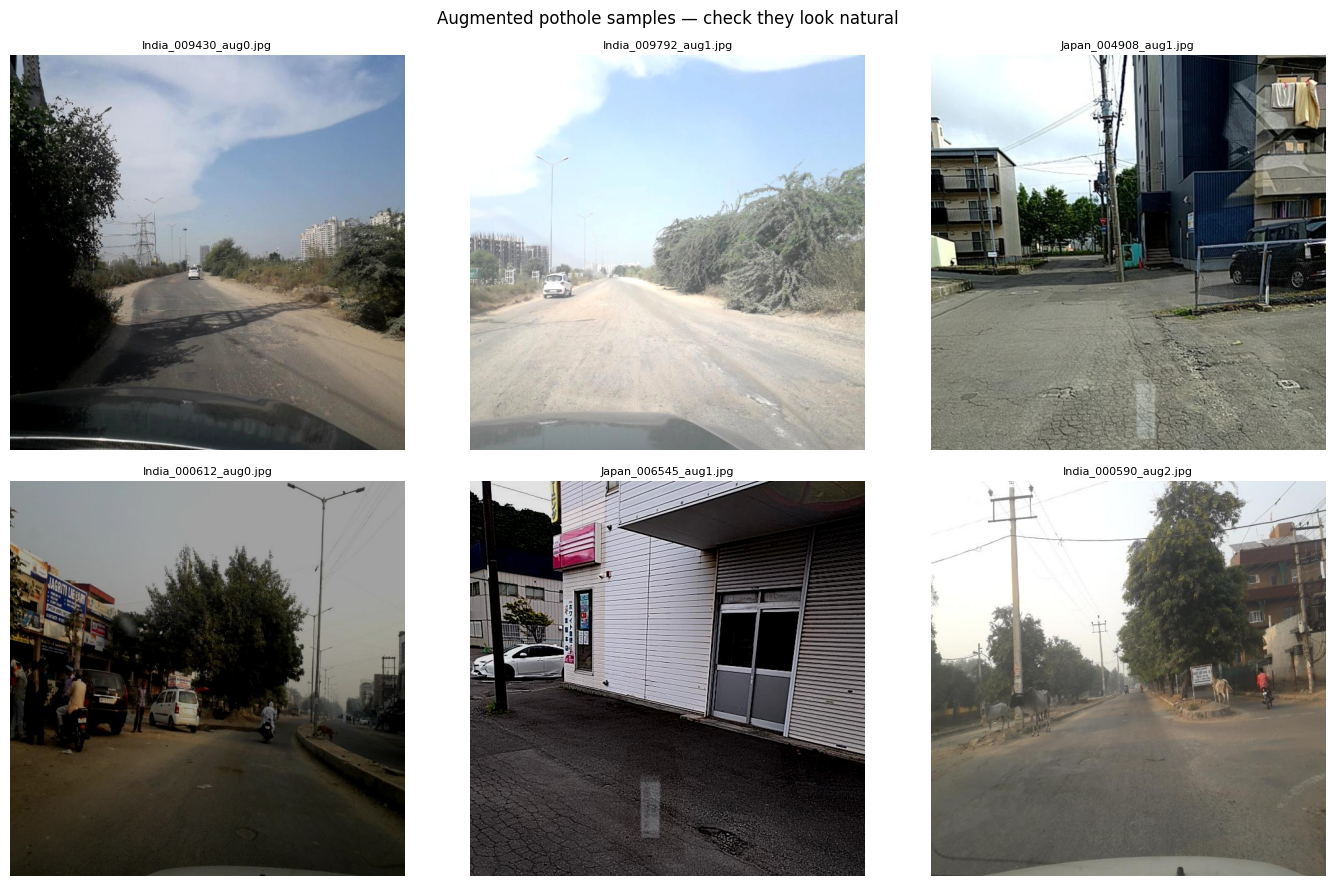

In [15]:
import random

aug_files = sorted(train_imgs.glob("*_aug*.jpg"))
samples = random.sample(list(aug_files), min(6, len(aug_files)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, path in zip(axes.flatten(), samples):
    img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(path.name, fontsize=8)
    ax.axis('off')

plt.suptitle('Augmented pothole samples — check they look natural', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Create YOLO dataset config

In [17]:
import yaml

YOLO_DIR = Path("/content/YOLO_V2")
YOLO_DIR.mkdir(parents=True, exist_ok=True)

for split in splits:
    paths = sorted(str(p.resolve()) for p in (WORK / split / "images").iterdir()
                   if p.suffix.lower() in ['.jpg', '.jpeg', '.png'])
    (YOLO_DIR / f"{split}.txt").write_text("\n".join(paths) + "\n")
    print(f"{split}: {len(paths)} images")

config = {
    'path': str(YOLO_DIR.resolve()),
    'train': str((YOLO_DIR / 'train.txt').resolve()),
    'val': str((YOLO_DIR / 'val.txt').resolve()),
    'test': str((YOLO_DIR / 'test.txt').resolve()),
    'nc': 3,
    'names': ['crack', 'other', 'pothole']
}

YAML_PATH = YOLO_DIR / 'dataset_v2.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(f"\n{YAML_PATH.read_text()}")

train: 34657 images
val: 5758 images
test: 5758 images

path: /content/YOLO_V2
train: /content/YOLO_V2/train.txt
val: /content/YOLO_V2/val.txt
test: /content/YOLO_V2/test.txt
nc: 3
names:
- crack
- other
- pothole



## 8. Train

| Setting | V1 | V2 | Why |
|---|---|---|---|
| `fliplr` | 0.0 | **0.5** | Biggest free gain — flipped road is still a road |
| `hsv_v` | 0.30 | **0.40** | Wider brightness range for different lighting |
| `mosaic` | 0.35 | **0.50** | More diversity per batch |
| `close_mosaic` | 10 | **15** | More clean-image fine-tuning at end |
| `translate` | 0.06 | **0.08** | Slightly more spatial variation |
| `scale` | 0.20 | **0.25** | Better near/far detection |
| Oversampling | x2 | **None** | Replaced with offline Albumentations |

In [18]:
from ultralytics import YOLO

SAVE_DIR = Path("/content/drive/MyDrive/SABIQ_runs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

model = YOLO("yolo26m.pt")

results = model.train(
    data=str(YAML_PATH),
    imgsz=640,
    epochs=100,
    patience=20,
    batch=16,
    device=0,
    optimizer='auto',
    cos_lr=True,
    amp=True,
    cache=False,
    workers=2,
    seed=42,

    # Save to Drive
    project=str(SAVE_DIR),
    name='sabiq_v2',
    exist_ok=True,
    save=True,
    save_period=5,
    verbose=True,

    # Geometric augmentation
    degrees=2.0,
    translate=0.08,
    scale=0.25,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,

    # Color augmentation
    hsv_h=0.01,
    hsv_s=0.45,
    hsv_v=0.40,

    # Mosaic
    mosaic=0.5,
    close_mosaic=15,
    mixup=0.0,
    copy_paste=0.0,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/YOLO_V2/dataset_v2.yaml, degrees=2.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.45, hsv_v=0.4, i

## 9. Resume training (if runtime disconnected)

In [ ]:
# Uncomment only if runtime disconnected
# from ultralytics import YOLO
# model = YOLO("/content/drive/MyDrive/SABIQ_runs/sabiq_v2/weights/last.pt")
# model.train(resume=True)

## 10. Check results

In [19]:
import pandas as pd
import os

run_dir = "/content/drive/MyDrive/SABIQ_runs/sabiq_v2"

weights = os.path.join(run_dir, "weights")
if os.path.exists(weights):
    for f in os.listdir(weights):
        size = os.path.getsize(os.path.join(weights, f)) / (1024*1024)
        print(f"{f}: {size:.1f} MB")

csv = os.path.join(run_dir, "results.csv")
if os.path.exists(csv):
    df = pd.read_csv(csv)
    df.columns = df.columns.str.strip()
    print(f"\nEpochs: {len(df)}")
    print(f"Best mAP50:    {df['metrics/mAP50(B)'].max():.4f}")
    print(f"Best mAP50-95: {df['metrics/mAP50-95(B)'].max():.4f}")
else:
    print("Results not found yet.")

last.pt: 42.0 MB
best.pt: 42.0 MB
epoch0.pt: 125.2 MB
epoch5.pt: 125.2 MB
epoch10.pt: 125.2 MB
epoch15.pt: 125.2 MB
epoch20.pt: 125.2 MB
epoch25.pt: 125.2 MB
epoch30.pt: 125.2 MB
epoch35.pt: 125.2 MB
epoch40.pt: 125.2 MB
epoch45.pt: 125.2 MB
epoch50.pt: 125.2 MB
epoch55.pt: 125.2 MB
epoch60.pt: 125.2 MB

Epochs: 65
Best mAP50:    0.6364
Best mAP50-95: 0.3489


In [20]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/SABIQ_runs/sabiq_v2/weights/best.pt")

metrics = model.val(
    data="/content/YOLO_V2/dataset_v2.yaml",
    split="val",
    plots=True
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1569.6±571.2 MB/s, size: 52.7 KB)
val: Scanning /content/RDD_V2/RDD_SPLIT/val/labels.cache... 5758 images, 1837 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 1.9Git/s 0.0s
val: /content/RDD_V2/RDD_SPLIT/val/images/Japan_004318.jpg: 1 duplicate labels removed
val: /content/RDD_V2/RDD_SPLIT/val/images/Japan_006536.jpg: 1 duplicate labels removed
val: /content/RDD_V2/RDD_SPLIT/val/images/Japan_007271.jpg: 1 duplicate labels removed
val: /content/RDD_V2/RDD_SPLIT/val/images/Japan_008673.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 10.2it/s 35.2s
                   all       5758       9737      0.692      0.584      0.637      0.349
                 crack 

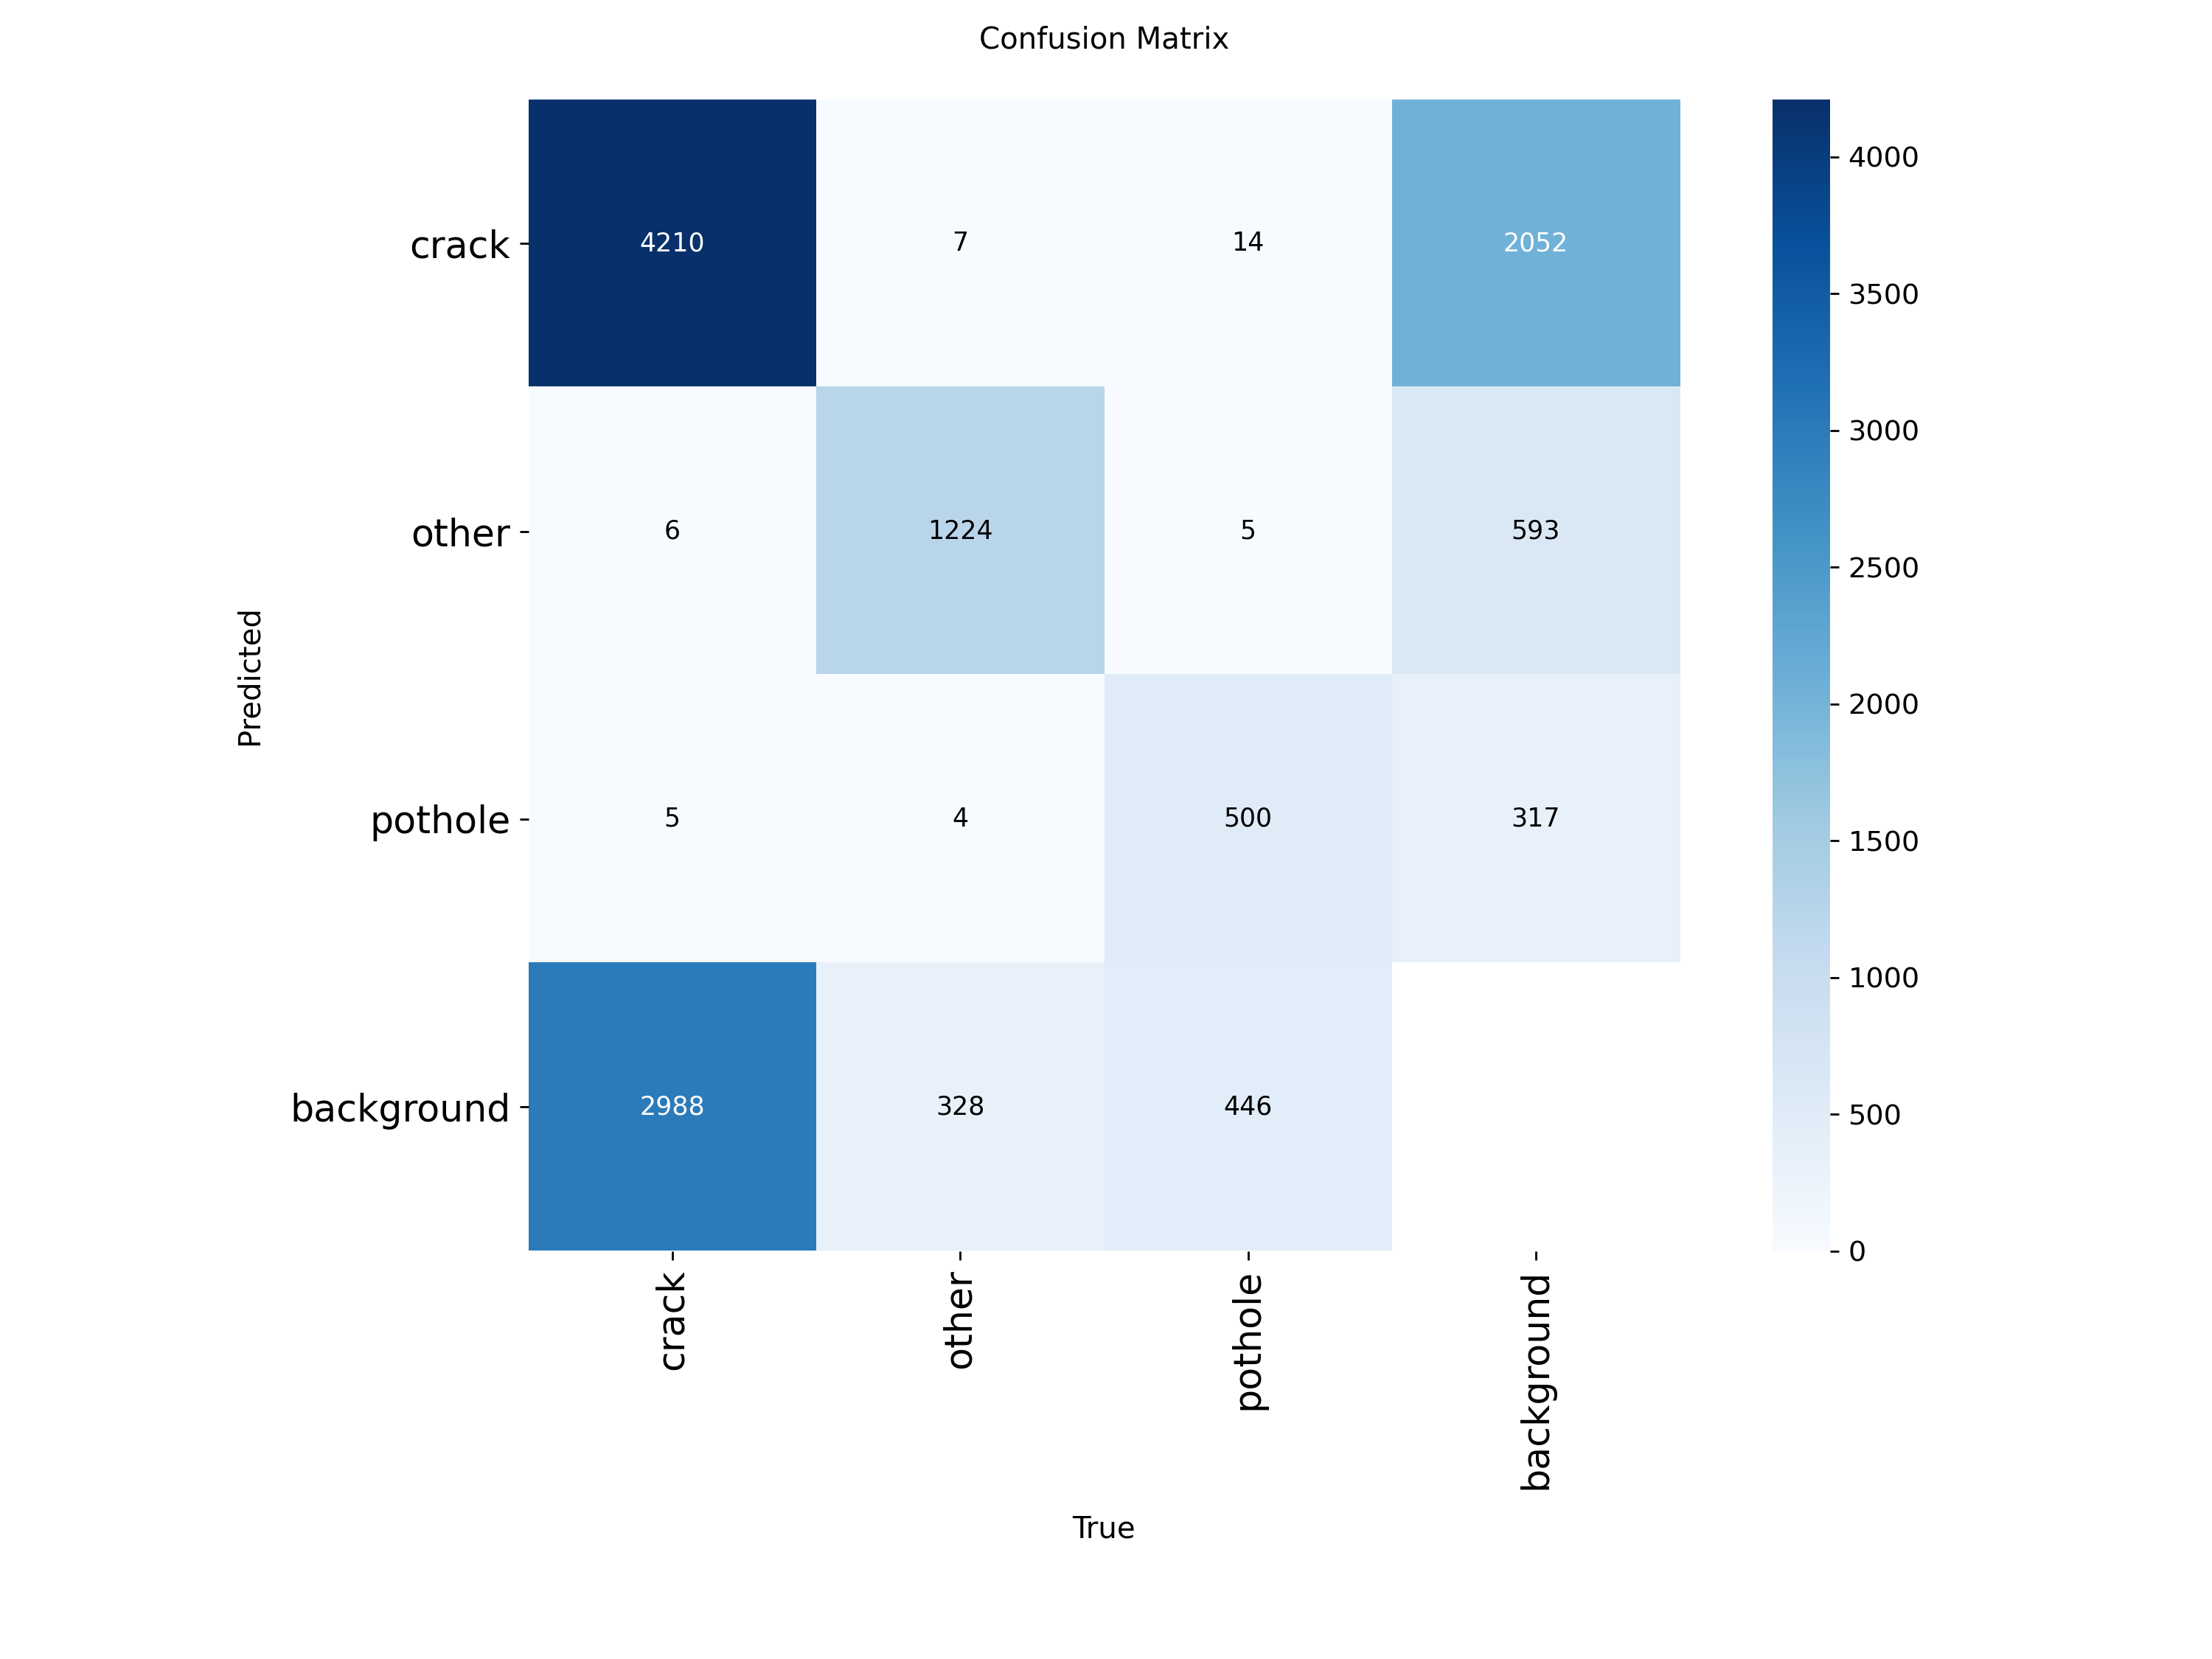

In [21]:
from IPython.display import Image, display

display(Image("/content/runs/detect/val/confusion_matrix.png", width=700))